<a href="https://colab.research.google.com/github/adilsher-dev/DEEP-LEARNING/blob/main/WineQualityPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Features shape: (178, 13)
Target shape: (178,)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names: ['class_0' 'class_1' 'class_2']
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.3009 - loss: 1.2601 - val_accuracy: 0.1724 - val_loss: 1.1821
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4956 - loss: 0.9936 - val_accuracy: 0.6552 - val_loss: 0.9091
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7788 - loss: 0.8065 - val_accuracy: 0.7931 - val_loss: 0.7148
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8673 - loss: 0.6642 - val_accuracy: 0.8621 - val_loss: 0.5877
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9115 - loss: 0.5526 - val_accuracy: 0.8966 - val_loss: 0.4893
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

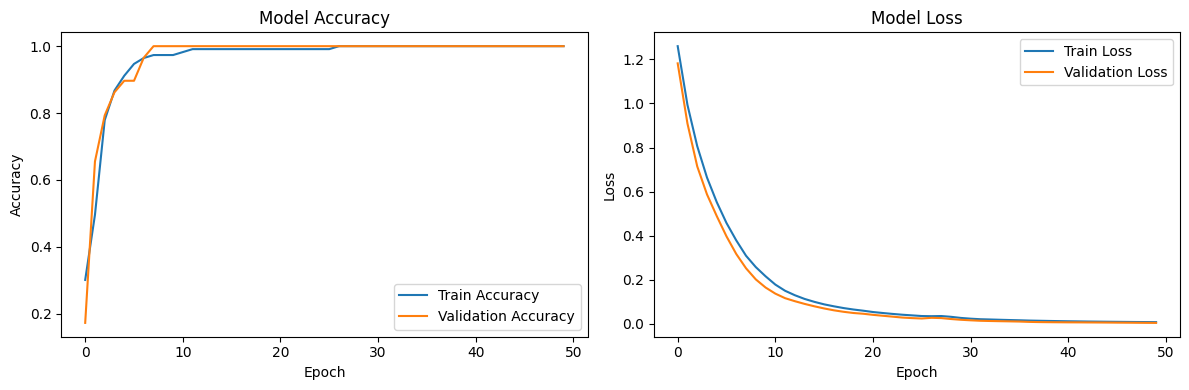


Predicted class: class_0
Actual class: class_0
Class probabilities: [1. 0. 0.]


In [1]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models


data = load_wine()
X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", data.feature_names)
print("Class names:", data.target_names)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose=0
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

sample_input = X_test[0:1]
probabilities = model.predict(sample_input, verbose=0)[0]

predicted_class = np.argmax(probabilities)

print("\nPredicted class:", data.target_names[predicted_class])
print("Actual class:", data.target_names[y_test[0]])
print("Class probabilities:", np.round(probabilities, 4))
